# K-means for color compression

Note that this notebook is intended as a demonstrative example of how the K-means algorithm works. Its focus is on the theory and results of its application, not on the code itself (which you will learn later). As such, it differs from other notebooks that accompany video lessons.

Specifically, some of the steps in the code exceed the scope of what is taught in the lessons. Pay attention to the cells' output, and not so much to the code that generates it.

This lab will:

Give you a worked example of K-means on non-synthetic data
Reinforce your understanding of K-means' underlying theory by demonstrating its affect when applied to a photograph
Before starting on this programming exercise, we strongly recommend watching the video lecture and completing the IVQ for the associated topics.

As we move forward, you can find instructions on how to install required libraries as they arise in this notebook.

**Modeling objective**
We will use K-means to cluster the pixels of a photograph of some tulips based on their encoded color values. We will explore how different values of k affect the clustering of the pixels, and thus the appearance of the photograph. We will also examine what is happening "under the hood" as the algorithm executes.

In [5]:
import numpy as np
import pandas as pd

%matplotlib  inline
import plotly.graph_objects as go

from sklearn.cluster import KMeans

**Read in data**
The "data" in this case is not a pandas dataframe. It's a photograph, which we'll convert into a numerical array.

In [6]:
# Read in a photo
img = plt.imread('using_kmeans_for_color_compression_tulips_photo.jpg')

(320, 240, 3)


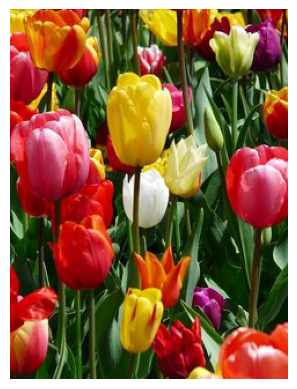

In [7]:
# Display the photo and its shape
print(img.shape)
plt.imshow(img)
plt.axis('off');

Here we have a photograph of some tulips. The shape of the image is 320 x 240 x 3. This can be interpreted as pixel information. Each dot on your screen is a pixel. This photograph has 320 vertical pixels and 240 horizontal pixels.

But what is the third dimension of "3"? This dimension refers to the values that encode the color of each pixel. Each pixel has 3 parameters: red (R), green (G), and blue (B), also known as its RGB values. For each color—R, G, and B—the encoded value can range from 0-255. This means that there are 256³, or 16,777,216 different combinations of RGB, each resulting in a unique color on your screen.

To prepare this data for modeling, we'll reshape it into an array, where each row represents a single pixel's RGB color values.

In [8]:
# Reshape the image so that each row represents a single pixel 
# defined by three values: R, G, B
img_flat = img.reshape(img.shape[0]*img.shape[1], 3)
img_flat[:5, :]

array([[211, 196,  41],
       [199, 180,  24],
       [179, 152,   0],
       [186, 150,   0],
       [187, 143,   0]], dtype=uint8)

In [9]:
img_flat.shape

(76800, 3)

**Plot the data in 3-D space**
Now we have an array that is 76,800 x 3. Each row is a single pixel's color values. Because we have only 3 columns, we can visualize this data in 3-dimensional space. Let's create a pandas dataframe to help us understand and visualize our data.

In [10]:
# Create a pandas df with r, g, and b as columns
img_flat_df = pd.DataFrame(img_flat, columns = ['r', 'g', 'b'])
img_flat_df.head()

,r,g,b
0,211,196,41
1,199,180,24
2,179,152,0
3,186,150,0
4,187,143,0


Note: The following cell's output is viewable in two ways: You can re-run this cell, or manually convert the notebook to "Trusted."

In [ ]:
# Create 3D plot where each pixel in the `img` is displayed in its actual color
trace = go.Scatter3d(x = img_flat_df.r,
                     y = img_flat_df.g,
                     z = img_flat_df.b,
                     mode='markers',
                     marker=dict(size=1,
                                 color=['rgb({},{},{})'.format(r,g,b) for r,g,b 
                                        in zip(img_flat_df.r.values, 
                                               img_flat_df.g.values, 
                                               img_flat_df.b.values)],
                                 opacity=0.5))

data = [trace]

layout = go.Layout(margin=dict(l=0,
                               r=0,
                               b=0,
                               t=0),
                               )

fig = go.Figure(data=data, layout=layout)
fig.update_layout(scene = dict(
                    xaxis_title='R',
                    yaxis_title='G',
                    zaxis_title='B'),
                  )
fig.show()

In this graph, each dot represents a color/pixel that is in our original image of tulips. The more intense the color, the more dots are concentrated in that area. The most-represented colors in the graph are the most abundant colors in the photograph: mostly reds, greens, and yellows. You can click and spin this graph to examine it from different angles. You can also zoom in and out.

We can train a K-means model on this data. The algorithm will create k clusters by minimizing the squared distances from each point to its nearest centroid.

Let's first do an experiment. What would you expect to happen if we built a K-means model with just a single centroid (k = 1) and replaced each pixel in the photograph with the RGB value of that centroid? What would the photograph look like?

Let's try it.

**Cluster the data: k = 1**

In [ ]:
# Instantiate the model
kmeans = KMeans(n_clusters=1, random_state=42).fit(img_flat)